This analysis processes 530,000+ raw observations to identify the power spectral density of Cambridge air temperature across varying timescales and whether different atmospheric fields exhibit distinct spectral fingerprints at the same site.

Data Source: University of Cambridge Computer Laboratory

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display, clear_output

from scipy.signal import periodogram
from scipy.signal import detrend

from scipy.signal import butter, filtfilt

In [2]:
filepath = "https://www.cl.cam.ac.uk/weather/weather-raw.csv" # URL pathway to the online data
df = pd.read_csv(filepath,header=None,parse_dates=[0],dayfirst=True) # convert the time column to "datetime" formatting

# parse some relevant time variables for subsequent analyses
time = df.iloc[:, 0] # grab the first column of time values
year = time.dt.year
dayofyear = time.dt.dayofyear
hour = time.dt.hour
minute = time.dt.minute
frac_day = (hour + minute / 60) / 24 # fraction of day
days_in_year = np.where(time.dt.is_leap_year, 366, 365) # account for leap years
year_decimal = year + (dayofyear - 1 + frac_day) / days_in_year # decimal year

# Place your (remaining) Question 1.1 code, here:
#rename column names in readable strings
df.columns = ['Timestamp', 'Temperature', 'Humid', 'DewPt', 'Press', 'WindSp',
              'WindDr', 'Sun', 'Rain', 'MxWSpd']
#convert raw temp. values to standard celsius (see explanation below)
df['Temp'] = df['Temperature'] / 10
#add year_decimal column to allow for using fractions of years later on
df['Year_Decimal'] = year_decimal
#remove any NaN values
df_clean = df.dropna()
#set Timestamp column as the index so can slice later on
df_clean = df_clean.set_index('Timestamp')
#extract on cleaned temp series
temp = df_clean['Temp']

#display first 5 rows to verify what we've done
#manually checked this on the Computer Lab website
print(temp.head())

/tmp/ipykernel_6462/2269154426.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv(filepath,header=None,parse_dates=[0],dayfirst=True) # convert the time column to "datetime" formatting


Timestamp
1995-06-30 15:00:00    29.5
1995-06-30 15:30:00    30.5
1995-06-30 16:00:00    31.1
1995-06-30 16:30:00    32.2
1995-06-30 17:00:00    32.7
Name: Temp, dtype: float64


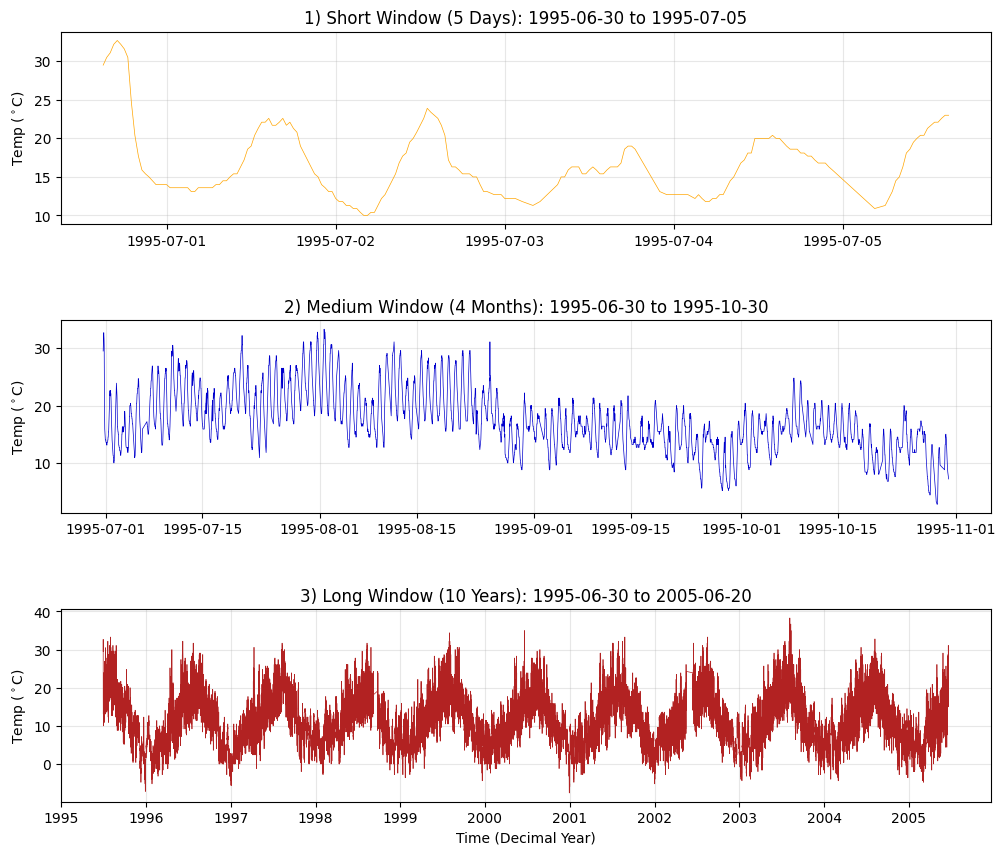

In [3]:
#specified 15:00 on end slice to ensure exactly 5 days worth of values
#as data only begins at 15:00 on 1995-06-30
short_w = temp['1995-06-30': '1995-07-05 15:00']
#medium window - synoptic weather & monthly shfits
medium_w = temp['1995-06-30': '1995-10-30']
#low-freq long window - captures annual(seasonal) cycle over a decade
long_w = temp['1995-06-30': '2005-06-20']

#set up vertical stack of 3 subplots for comparison
fig, axes = plt.subplots(3, 1, figsize = (12,10))

#first plot subplot - 5 day span
axes[0].plot(short_w.index, short_w.values, color='orange', lw = 0.5)
#uses strftime to extract & format the start & end dates for title
axes[0].set_title(f'1) Short Window (5 Days): {short_w.index[0].strftime("%Y-%m-%d")} to {short_w.index[-1].strftime("%Y-%m-%d")}')
#r for raw string, was reading the backslash as a command
axes[0].set_ylabel(r'Temp ($^\circ$C)')

#second subplot - 4 months
axes[1].plot(medium_w.index, medium_w.values, color='mediumblue', lw = 0.5)
axes[1].set_title(f'2) Medium Window (4 Months): {medium_w.index[0].strftime("%Y-%m-%d")} to {medium_w.index[-1].strftime("%Y-%m-%d")}')
axes[1].set_ylabel(r'Temp ($^\circ$C)')

#third subplot - 10 year
axes[2].plot(long_w.index, long_w.values, color='firebrick', lw = 0.5)
axes[2].set_title(f'3) Long Window (10 Years): {long_w.index[0].strftime("%Y-%m-%d")} to {long_w.index[-1].strftime("%Y-%m-%d")}')
axes[2].set_xlabel('Time (Decimal Year)')
axes[2].set_ylabel(r'Temp ($^\circ$C)')

#chose shades of orange, blue, & red for maximum contrast and to be accessible

#increasing spacing between the plot as it was all a bit cramped without this
plt.subplots_adjust(hspace = 0.5)

#add a faint grid to all the axes through for loop for ease
for ax in axes:
    ax.grid(True, alpha = 0.3)

#display the figure
plt.show()

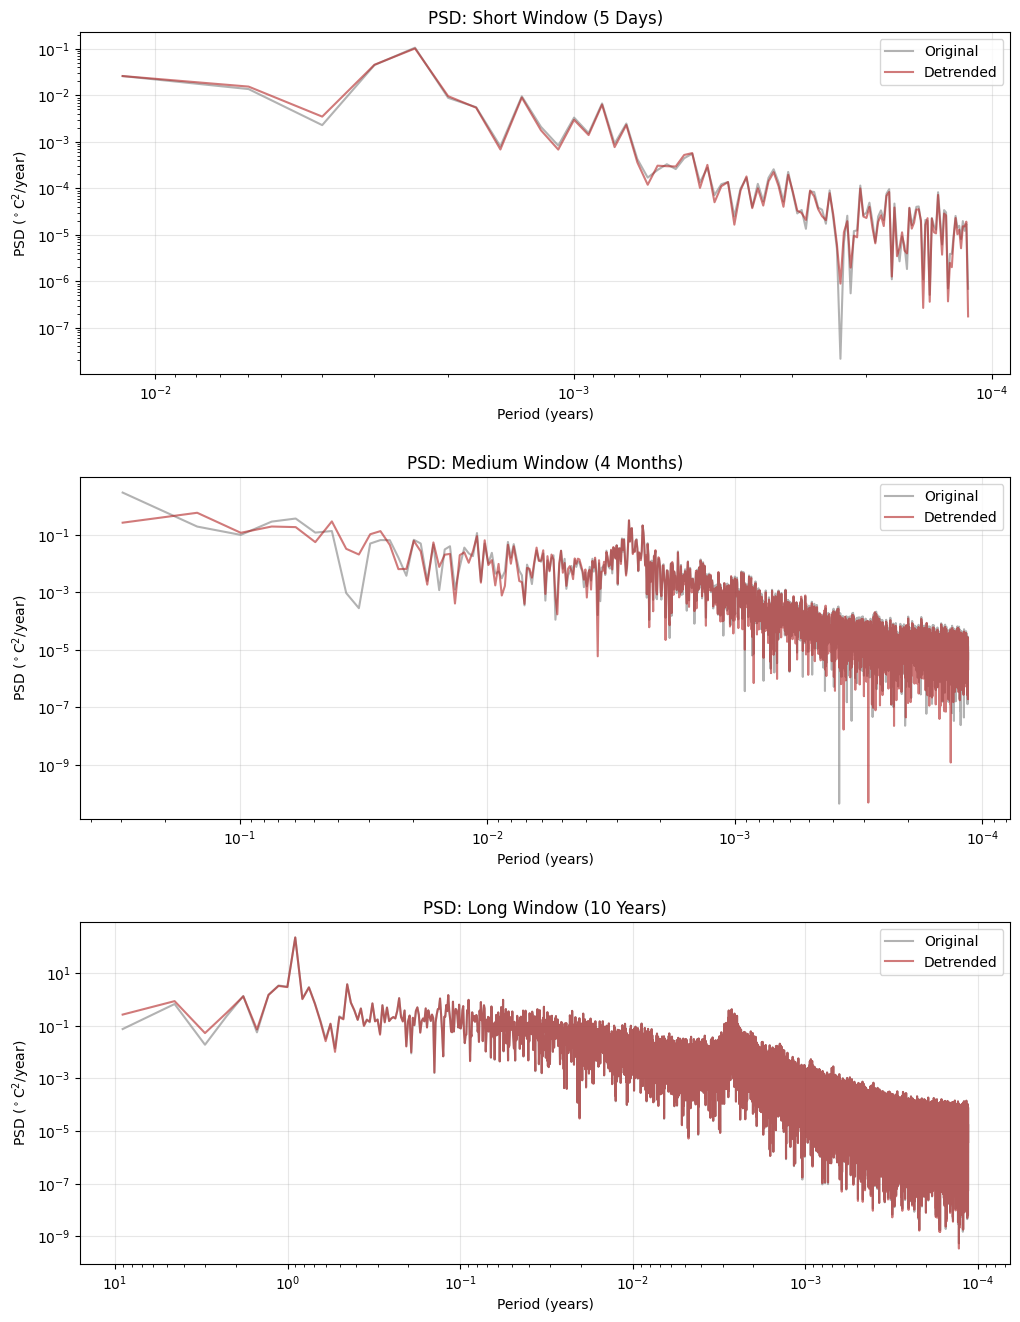

In [4]:
#sampling intervals in years
#48 samples a day, 365.25 days per year
dt = 1 / (48*365.25)
#sampling frequency is inverse of sampling interval (cyles/year)
fs = 1 / dt
##fs is defined via dt explicitly to make the derivation clear as sampling
  #frequency is the inverse of sampling interval

#set up vertical 3 subplot figure to compare PSD of each window from 1.2
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

#group the slices & labels
windows = [short_w, medium_w, long_w]
labels = ['Short Window (5 Days)', 'Medium Window (4 Months)', 'Long Window (10 Years)']

#use enumerate to loop through each axes while keeping track of the index [i]
for i, ax in enumerate(axes):
  #periodogram (PSD) of raw windowed data
  f, Pxx = periodogram(windows[i], fs)
  #apply detrend to data to remove any non-stationary mean shifts
  data_detrend = detrend(windows[i])
  #compute periodogram of the detrended data for changes in spectral peaks
  frequency_detrend, Pxx_detrend = periodogram(data_detrend, fs)
  #convert frequency into periods, & skip 0th index to avoid division by 0
  periods = 1 / f[1:]
  #plot both on log-log scale to visualise the several orders of magnitude in
  # both period & PSD.
  #log-log turn the exponential relationships into straight lines so peaks
  #can be seen very easily
  ax.loglog(periods, Pxx[1:], label='Original', color='grey', alpha=0.6)
  ax.loglog(periods, Pxx_detrend[1:], label='Detrended', color='firebrick', alpha=0.6)

  #set labels from above
  ax.set_title(f'PSD: {labels[i]}')
  ax.set_xlabel('Period (years)')
  #PSD units as squared per unit frequency (year)
  ax.set_ylabel(r'PSD ($^\circ$C$^2$/year)')
  #invert x axis for visualisation so the longer periods (years) are on the left
  #& the shorter (days) are on the right - prefer the way this explains the data
  ax.invert_xaxis()
  ax.grid(True,alpha=0.3)
  ax.legend()

#again, creating a bit of space between the plots
plt.subplots_adjust(hspace=0.3)
plt.show()


In [5]:
data = long_w
#periodogram for PSD
f, Pxx = periodogram (data, fs)
#frequency reolsution, to integrate PSD across specified frequency bands
df_freq = f[1] - f[0]
#calculate total variance by integrating entire PSD
total_var = np.sum(Pxx) * df_freq
#define spectral mesk to isolate annual cycle, centred at 1.0 cycle/year (+/- 10%)
annual_mask = (f >= 0.8) & (f <= 1.2)
annual_var = np.sum(Pxx[annual_mask]) * df_freq
#define spectral mask to isolate diurnal cycle (~ 365.25 cycles/year)
diurnal_mask = (f >= 350) & (f <= 380)
diurnal_var = np.sum(Pxx[diurnal_mask]) * df_freq
#calculate percentage contribution of the cycles to total temp. variability
frac_ann = (annual_var / total_var) * 100
frac_diurnal = (diurnal_var / total_var) * 100
#print summaries
print(f'Annual Variance Fraction: {frac_ann:.2f}%')
print(f'Diurnal Variance Fraction: {frac_diurnal:.2f}%')
print(f"Total Variance: {total_var:.2f}")
print(f'Annual Band Variance: {annual_var:.2f} °C²')
print(f'Diurnal Band Variance: {diurnal_var:.2f} °C²')

Annual Variance Fraction: 58.79%
Diurnal Variance Fraction: 4.30%
Total Variance: 42.88
Annual Band Variance: 25.21 °C²
Diurnal Band Variance: 1.84 °C²


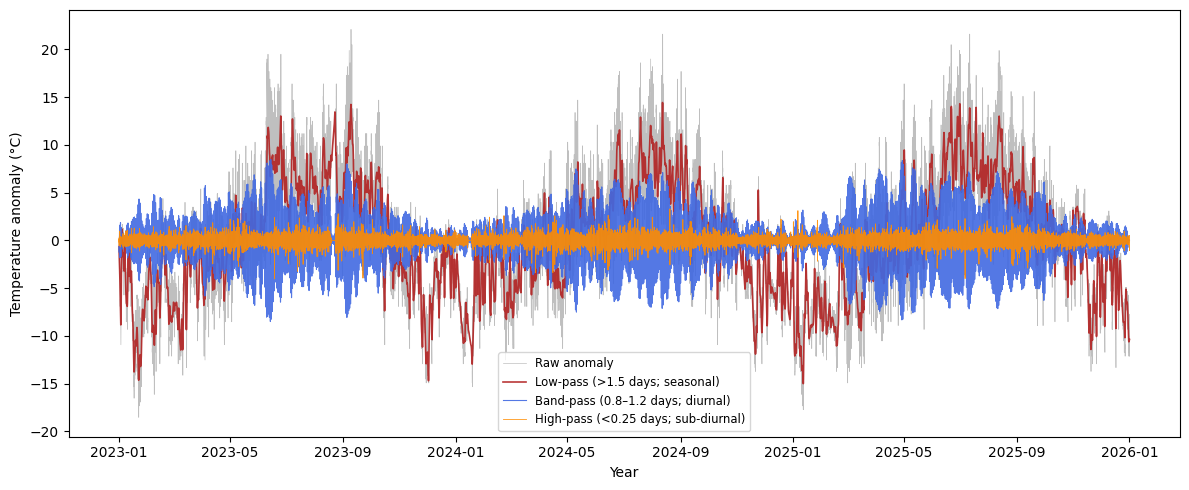

In [6]:
time_grid = pd.date_range(start ='2023-01-01', end = '2025-12-31 23:30:00',
                          freq = '30min')
#reindex & interpolate to fill gaps
temp_continuous = temp['2023-01-01':'2025-12-31'].reindex(time_grid).interpolate()
#subtract mean to create a raw anomaly
data_to_filter = temp_continuous.values - np.mean(temp_continuous.values)

#frequency calculation
dt = 1/48
fs = 1/dt

#set cutoffs for the regimes
f_cutoff_lp = 1/1.5 # isolating cycles longer than 1.5 days
f_cutoff_hp = 1/0.25 # isolating cycles shorter than 6 hours
f_diurnal_low = 1/1.2 # lower bound for band-pass
f_diurnal_high = 1/0.8 # upper bound for band pass

#define a bandpass function with butterworth
def bandpass_filter(data, low_cut, high_cut, fs=fs, order=4):
    nyquist = 0.5 * fs
    low = min(low_cut, high_cut) / nyquist
    high = max(low_cut, high_cut) / nyquist
    #filter parameters
    b, a = butter(order, [low, high], btype='band')
    #filtfilt to prevent filtered signal from shitfing in time relative to original
    return filtfilt(b, a, data)

#filtered components, low-pass capture the envelope of the signal
b_lp, a_lp = butter(4, f_cutoff_lp/(0.5*fs), btype='low')
lp_temp = filtfilt(b_lp, a_lp, data_to_filter)
#bandpass to isolate diurnal
bp_temp = bandpass_filter(data_to_filter, f_diurnal_low, f_diurnal_high)
#high pass to isolate more rapid fluctuations (under 6 hours)
b_hp, a_hp = butter(4, f_cutoff_hp/(0.5*fs), btype='high')
hp_temp = filtfilt(b_hp, a_hp, data_to_filter)

#plotting all on one axis
fig, ax = plt.subplots(figsize=(12, 5))
#keep original grey more transparent
ax.plot(time_grid, data_to_filter, color='grey', alpha = 0.5, lw = 0.5,
        label = 'Raw anomaly')
ax.plot(time_grid, lp_temp, color = 'firebrick', alpha = 0.9, lw = 1.2,
        label='Low-pass (>1.5 days; seasonal)')
ax.plot(time_grid, bp_temp, color = 'royalblue', alpha = 0.9, lw = 0.8,
        label='Band-pass (0.8–1.2 days; diurnal)')
ax.plot(time_grid, hp_temp, color = 'darkorange', alpha = 0.9, lw = 0.6,
        label='High-pass (<0.25 days; sub-diurnal)')
#orange, red, blue for high contrast & accessibility

ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (°C)')
#legend in most space
ax.legend(loc = 'lower center', fontsize = 'small')
plt.tight_layout()
plt.show()



The signal was decomposed using three filters to isolate distinct drivers. The low-pass filter (> 1.5 days) isolates the background and seasonal forcing. Schulz & Mudelsee (2002) show this is dominated by a red-noise process, representing large-scale synoptic weather and the annual cycle. The band-pass filter (0.8-1.2 days) targets the phase-coherent diurnal cycle as discussed in Meyers et al.(2008). This is the 24-hour cycle of solar radiation forcing the Earth's surface. By isolating this, we separate the solar forcing from random noise. The high-pass filter captures high-frequencies. This could be localised convective turbulence occurring on timescales too rapid to be part of a climate signal. The low-pass contains the most power with seasonal variance, while the band-pass reveals daily rhythms, and the high-pass the sub-daily noise.

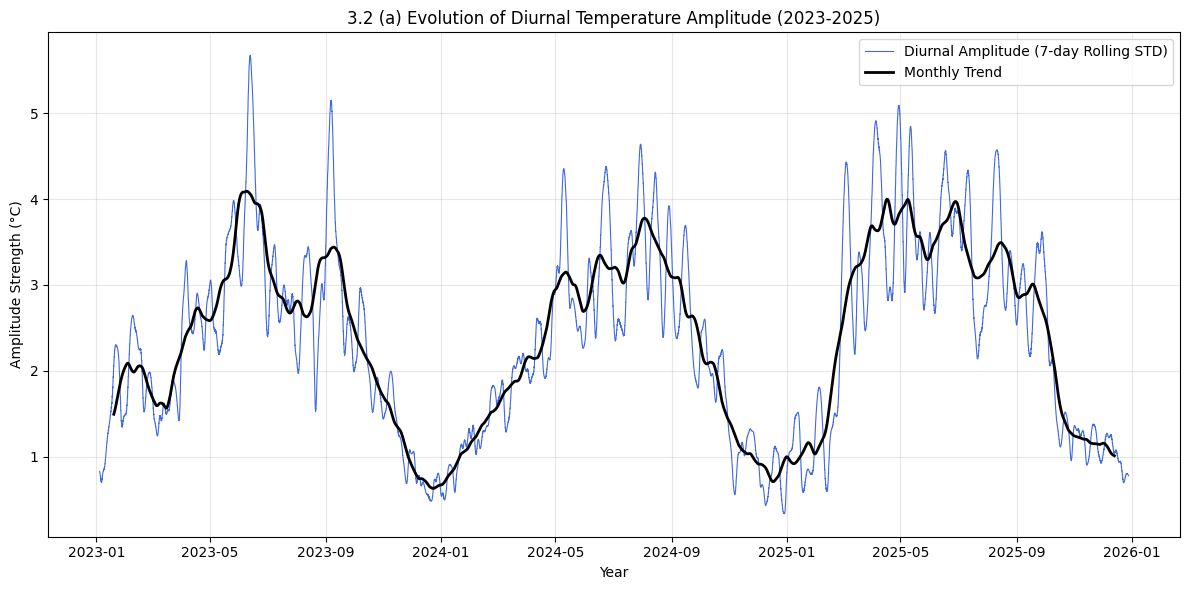

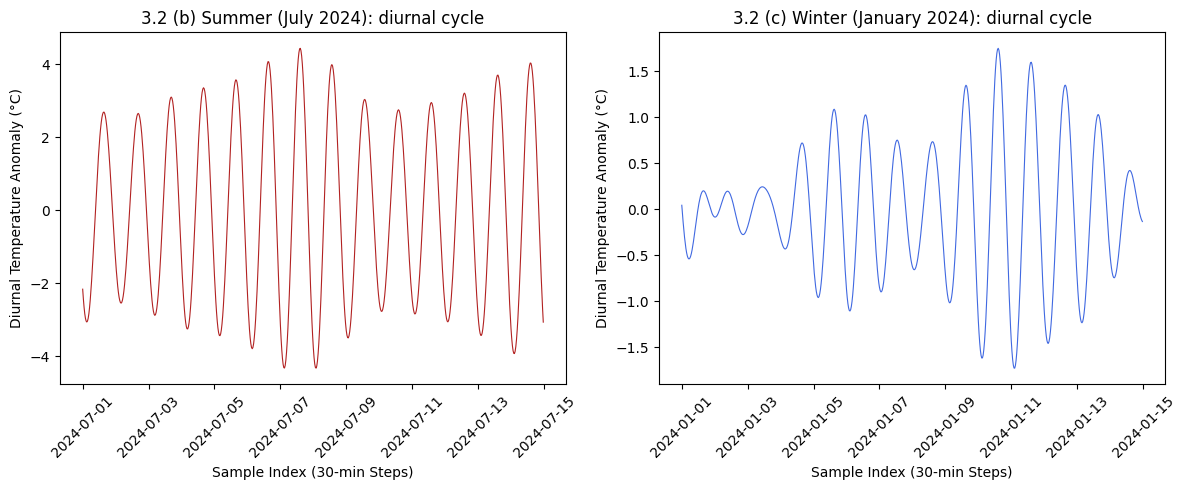

In [7]:
#define size for the rolling statistic, 7 days multiplied by 48 samples a day
#weekly window removes any day-to-day noise
window_size = 48 * 7
#standard deviation to extract the envelope of diurnal cycle
#magnitude of the daily changes quantified
diurnal_amplitude = pd.Series(bp_temp,
                              index=time_grid).rolling(window = window_size,
                                                       center = True).std()
#plotting
plt.figure(figsize = (12,6))
#plot 7 day rolling amplitude to show short-term changes
plt.plot(time_grid, diurnal_amplitude, color = 'royalblue', lw = 0.8,
         label = 'Diurnal Amplitude (7-day Rolling STD)')
#overlay a 30-day rolling mean for longer-term seasonal trends
#shows during which parts of the year the cycle is stronger
plt.plot(time_grid, diurnal_amplitude.rolling(window = 48 * 30, center = True).mean(),
         color = 'black', lw = 2, label = 'Monthly Trend')
#plotting
plt.title('3.2 (a) Evolution of Diurnal Temperature Amplitude (2023-2025)')
plt.xlabel('Year')
plt.ylabel('Amplitude Strength (°C)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

## Fig 2 ##
#2 subplots to compare the diurnal cycle in summer vs. winter 2024
#done to highlight the difference in cycle strength visible in 3.2(a)
fig, axes = plt.subplots(1, 2, figsize = (12,5))
#create a 7 day slice for each season
summer_slice = slice('2024-07-01', '2024-07-14')
winter_slice = slice('2024-01-01', '2024-01-14')

#convert to series with dates
bp_series = pd.Series(bp_temp, index=time_grid)

#plot the summer slice in red
axes[0].plot(bp_series[summer_slice], color = 'firebrick', lw = 0.8)
axes[0].set_title('3.2 (b) Summer (July 2024): diurnal cycle')
axes[0].set_xlabel('Sample Index (30-min Steps)')
axes[0].set_ylabel('Diurnal Temperature Anomaly (°C)')
#angled the x axis labels for space
axes[0].tick_params(axis='x', labelrotation=45)
#plot the winter slice in blue
axes[1].plot(bp_series[winter_slice], color = 'royalblue', lw = 0.8)
axes[1].set_title('3.2 (c) Winter (January 2024): diurnal cycle')
axes[1].set_xlabel('Sample Index (30-min Steps)')
axes[1].set_ylabel('Diurnal Temperature Anomaly (°C)')
#angled the x axis labels for space
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

The analysis reveals a clear seasonal modulation, where the magnitude of daily temperatrue changes are non-stationary, and non-random. The primary variation here is the significant increase in amplitude during summer months (3.2(b)) contrasted with winter (3.2(c)). Physically, this is driven by the annual solar cycle. Summer has higher solar irradiance and longer days, creating a larger thermal gradient between daytime heating and nocturnal cooling. In winter, solar angles are lower and cloud cover is more likely which work to dampen surface heating, causing the diurnal cycle to be weaker. The sun is seasonally modulated, and the remaining variability is background continuum driven by unpredicability (Meyers et al., 2008).